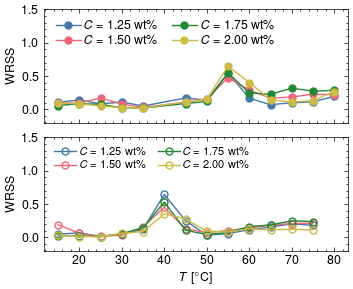

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'nature', 'bright'])

# ------------------ Settings ------------------
concentrations = [1.25, 1.50, 1.75, 2.00]
data_base_dir = "../results"   # adjust if your CSVs are elsewhere
figures_dir = "../figures/main/error_vs_temperature"
os.makedirs(figures_dir, exist_ok=True)  # make sure folder exists

# ------------------ Load Data ------------------
heating_data = {}
cooling_data = {}

for c in concentrations:
    conc_str = f"{c:.2f}"  # e.g., "1.25"

    heat_file = os.path.join(data_base_dir, conc_str, f"cost_heating_concentration_{conc_str}.csv")
    cool_file = os.path.join(data_base_dir, conc_str, f"cost_data_cooling_concentration_{conc_str}.csv")

    if os.path.exists(heat_file):
        heating_data[c] = pd.read_csv(heat_file)
    else:
        print(f"Warning: Heating file not found: {heat_file}")

    if os.path.exists(cool_file):
        cooling_data[c] = pd.read_csv(cool_file)
    else:
        print(f"Warning: Cooling file not found: {cool_file}")

# ------------------ Plot ------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(3.640625, 3.0), sharex=True,
    gridspec_kw={'height_ratios': [1, 1]}
)

# --- Heating ---
for c in concentrations:
    if c in heating_data:
        df = heating_data[c]
        ax1.plot(df["Temperature_C"], df["Cost"], 
                 marker='o', markersize=5,
                 label=f'$C$ = {c:.2f} wt\%')

ax1.set_ylabel('WRSS', fontsize=9)
ax1.tick_params(axis='both', which='major', labelsize=9)
ax1.set_ylim(-0.2, 1.5)
ax1.legend(loc='upper left', fontsize=9, ncol=2,
           handletextpad=0.3,
           labelspacing=0.3,
           columnspacing=1.0)

# --- Cooling ---
for c in concentrations:
    if c in cooling_data:
        df = cooling_data[c]
        ax2.plot(df["Temperature_C"], df["Cost"], 
                 marker='o', markersize=5, fillstyle='none',
                 label=f'$C$ = {c:.2f} wt\%')

ax2.set_ylabel('WRSS', fontsize=9)
ax2.tick_params(axis='both', which='major', labelsize=9)
ax2.set_ylim(-0.2, 1.5)
ax2.legend(loc='upper left', fontsize=8, ncol=2,
           handletextpad=0.3,
           labelspacing=0.3,
           columnspacing=1.0)

# Common x-axis
ax2.set_xlabel('$T$ [$^{\circ}$C]', fontsize=9)

plt.tight_layout()

# Save figure
out_path = os.path.join(figures_dir, "fitting_error_vs_temperature.pdf")
plt.savefig(out_path, dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()
